# Three-Stage Multimodal Model — MHC Class I




In [1]:
import os
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, roc_auc_score,
                             confusion_matrix, classification_report)
from Bio.Align import substitution_matrices
import matplotlib.pyplot as plt

DATA_PATH = "/Users/shubhaychoubey/Documents/GitHub/Peptide/Data/ML_Ready/IEDB_ML_ready_with_seq_with_HLA.csv"
CACHE_DIR = "/Users/shubhaychoubey/Documents/GitHub/Peptide/Methods/cache"
os.makedirs(CACHE_DIR, exist_ok=True)

MAX_PEP_LEN = 11          
N_TOP_BIO   = 8           
RANDOM_STATE = 234
USE_ESM2 = False          

device = torch.device("mps" if torch.backends.mps.is_available()
                      else "cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
print("Device:", device)
print("CHANGE DEVICE DEPENEDENT ON YOUR COMPUTER")

Device: mps
CHANGE DEVICE DEPENEDENT ON YOUR COMPUTER


## 1. Load class I data, drop leaks, split

In [2]:
hla_library = {
    # HLA-A*24:02  →  IMGT/HLA source allele: A*24:02:01:01
    "HLA-A*24:02": (
        "GSHSMRYFSTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRMEPRAPWIEQEGPEYW"
        "DEETGKVKAHSQTDRENLRIALRYYNQSEAGSHTLQMMFGCDVGSDGRFLRGYHQYAYDG"
        "KDYIALKEDLRSWTAADMAAQITKRKWEAAHVAEQQRAYLEGTCVDGLRRYLENGKETLQ"
        "RTDPPKTHMTHHPISDHEATLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDGT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPKPLTLRW"
    ),
 
    # HLA-A*02:01  →  IMGT/HLA source allele: A*02:01:01:01
    "HLA-A*02:01": (
        "GSHSMRYFFTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRMEPRAPWIEQEGPEYW"
        "DGETRKVKAHSQTHRVDLGTLRGYYNQSEAGSHTVQRMYGCDVGSDWRFLRGYHQYAYDG"
        "KDYIALKEDLRSWTAADMAAQTTKHKWEAAHVAEQLRAYLEGTCVEWLRRYLENGKETLQ"
        "RTDAPKTHMTHHAVSDHEATLRCWALSFYPAEITLTWQRDGEDQTQDTELVETRPAGDGT"
        "FQKWAAVVVPSGQEQRYTCHVQHEGLPKPLTLRW"
    ),
 
    # HLA-A*32:01  →  IMGT/HLA source allele: A*32:01:01:01
    "HLA-A*32:01": (
        "GSHSMRYFFTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRMEPRAPWIEQEGPEYW"
        "DQETRNVKAHSQTDRESLRIALRYYNQSEAGSHTIQMMYGCDVGPDGRLLRGYQQDAYDG"
        "KDYIALNEDLRSWTAADMAAQITQRKWEAARVAEQLRAYLEGTCVEWLRRYLENGKETLQ"
        "RTDAPKTHMTHHAVSDHEATLRCWALSFYPAEITLTWQRDGEDQTQDTELVETRPAGDGT"
        "FQKWASVVVPSGQEQRYTCHVQHEGLPKPLTLRW"
    ),
 
    # HLA-B*15:10  →  IMGT/HLA source allele: B*15:10:01:01
    "HLA-B*15:10": (
        "GSHSMRYFYTAMSRPGRGEPRFISVGYVDDTQFVRFDSDAASPREEPRAPWIEQEGPEYW"
        "DRNTQICKTNTQTYRESLRNLRGYYNQSEAGSHTLQRMYGCDVGPDGRLLRGHDQYAYDG"
        "KDYIALNEDLSSWTAADTAAQITQRKWEAAREAEQLRAYLEGLCVEWLRRYLENGKETLQ"
        "RADPPKTHVTHHPISDHEATLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDRT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPKPLTLRW"
    ),
 
    # HLA-C*03:04  →  IMGT/HLA source allele: C*03:04:01:01
    "HLA-C*03:04": (
        "GSHSMRYFYTAVSRPGRGEPHFIAVGYVDDTQFVRFDSDAASPRGEPRAPWVEQEGPEYW"
        "DRETQKYKRQAQTDRVSLRNLRGYYNQSEAGSHIIQRMYGCDVGPDGRLLRGYDQYAYDG"
        "KDYIALNEDLRSWTAADTAAQITQRKWEAAREAEQLRAYLEGLCVEWLRRYLKNGKETLQ"
        "RAEHPKTHVTHHPVSDHEATLRCWALGFYPAEITLTWQWDGEDQTQDTELVETRPAGDGT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPEPLTLRW"
    ),
 
    # HLA-C*14:02  →  IMGT/HLA source allele: C*14:02:01:01
    "HLA-C*14:02": (
        "CSHSMRYFSTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASPRGEPRAPWVEQEGPEYW"
        "DRETQKYKRQAQTDRVSLRNLRGYYNQSEAGSHTLQWMFGCDLGPDGRLLRGYDQSAYDG"
        "KDYIALNEDLRSWTAADTAAQITQRKWEAAREAEQRRAYLEGTCVEWLRRYLENGKETLQ"
        "RAEHPKTHVTHHPVSDHEATLRCWALGFYPAEITLTWQWDGEDQTQDTELVETRPAGDGT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPEPLTLRW"
    ),
 
    # HLA-B*44:02  →  IMGT/HLA source allele: B*44:02:01:01
    "HLA-B*44:02": (
        "GSHSMRYFYTAMSRPGRGEPRFITVGYVDDTLFVRFDSDATSPRKEPRAPWIEQEGPEYW"
        "DRETQISKTNTQTYRENLRTALRYYNQSEAGSHIIQRMYGCDVGPDGRLLRGYDQDAYDG"
        "KDYIALNEDLSSWTAADTAAQITQRKWEAARVAEQDRAYLEGLCVESLRRYLENGKETLQ"
        "RADPPKTHVTHHPISDHEVTLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDRT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPKPLTLRW"
    ),
 
    # HLA-B*57:01  →  IMGT/HLA source allele: B*57:01:01:01
    "HLA-B*57:01": (
        "GSHSMRYFYTAMSRPGRGEPRFIAVGYVDDTQFVRFDSDAASPRMAPRAPWIEQEGPEYW"
        "DGETRNMKASAQTYRENLRIALRYYNQSEAGSHIIQVMYGCDVGPDGRLLRGHDQSAYDG"
        "KDYIALNEDLSSWTAADTAAQITQRKWEAARVAEQLRAYLEGLCVEWLRRYLENGKETLQ"
        "RADPPKTHVTHHPISDHEATLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDRT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPKPLTLRW"
    ),
 
    # HLA-A*03:01  →  IMGT/HLA source allele: A*03:01:01:01
    "HLA-A*03:01": (
        "GSHSMRYFFTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRMEPRAPWIEQEGPEYW"
        "DQETRNVKAQSQTDRVDLGTLRGYYNQSEAGSHTIQIMYGCDVGSDGRFLRGYRQDAYDG"
        "KDYIALNEDLRSWTAADMAAQITKRKWEAAHEAEQLRAYLDGTCVEWLRRYLENGKETLQ"
        "RTDPPKTHMTHHPISDHEATLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDGT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPKPLTLRW"
    ),
 
    # HLA-C*05:01  →  IMGT/HLA source allele: C*05:01:01:01
    "HLA-C*05:01": (
        "CSHSMRYFYTAVSRPGRGEPRFIAVGYVDDTQFVQFDSDAASPRGEPRAPWVEQEGPEYW"
        "DRETQKYKRQAQTDRVNLRKLRGYYNQSEAGSHTLQRMYGCDLGPDGRLLRGYNQFAYDG"
        "KDYIALNEDLRSWTAADKAAQITQRKWEAAREAEQRRAYLEGTCVEWLRRYLENGKKTLQ"
        "RAEHPKTHVTHHPVSDHEATLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDGT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPEPLTLRW"
    ),
 
    # HLA-B*27:05  →  IMGT/HLA source allele: B*27:05:02:01
    "HLA-B*27:05": (
        "GSHSMRYFHTSVSRPGRGEPRFITVGYVDDTLFVRFDSDAASPREEPRAPWIEQEGPEYW"
        "DRETQICKAKAQTDREDLRTLLRYYNQSEAGSHTLQNMYGCDVGPDGRLLRGYHQDAYDG"
        "KDYIALNEDLSSWTAADTAAQITQRKWEAARVAEQLRAYLEGECVEWLRRYLENGKETLQ"
        "RADPPKTHVTHHPISDHEATLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDRT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPKPLTLRW"
    ),
 
    # HLA-B*51:01  →  IMGT/HLA source allele: B*51:01:01:01
    "HLA-B*51:01": (
        "GSHSMRYFYTAMSRPGRGEPRFIAVGYVDDTQFVRFDSDAASPRTEPRAPWIEQEGPEYW"
        "DRNTQIFKTNTQTYRENLRIALRYYNQSEAGSHTWQTMYGCDVGPDGRLLRGHNQYAYDG"
        "KDYIALNEDLSSWTAADTAAQITQRKWEAAREAEQLRAYLEGLCVEWLRRHLENGKETLQ"
        "RADPPKTHVTHHPVSDHEATLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDRT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPKPLTLRW"
    ),
 
    # HLA-B*40:01  →  IMGT/HLA source allele: B*40:01:01
    "HLA-B*40:01": (
        "GSHSMRYFHTAMSRPGRGEPRFITVGYVDDTLFVRFDSDATSPRKEPRAPWIEQEGPEYW"
        "DRETQISKTNTQTYRESLRNLRGYYNQSEAGSHTLQRMYGCDVGPDGRLLRGHNQYAYDG"
        "KDYIALNEDLRSWTAADTAAQISQRKLEAARVAEQLRAYLEGECVEWLRRYLENGKDKLE"
        "RADPPKTHVTHHPISDHEATLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDRT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPKPLTLRW"
    ),
 
    # HLA-B*40:02  →  IMGT/HLA source allele: B*40:02:01:01
    "HLA-B*40:02": (
        "GSHSMRYFHTSVSRPGRGEPRFITVGYVDDTLFVRFDSDATSPRKEPRAPWIEQEGPEYW"
        "DRETQISKTNTQTYRESLRNLRGYYNQSEAGSHTLQSMYGCDVGPDGRLLRGHNQYAYDG"
        "KDYIALNEDLRSWTAADTAAQITQRKWEAARVAEQLRAYLEGECVEWLRRYLENGKETLQ"
        "RADPPKTHVTHHPISDHEATLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDRT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPKPLTLRW"
    ),
 
    # HLA-B*07:02  →  IMGT/HLA source allele: B*07:02:01:01
    "HLA-B*07:02": (
        "GSHSMRYFYTSVSRPGRGEPRFISVGYVDDTQFVRFDSDAASPREEPRAPWIEQEGPEYW"
        "DRNTQIYKAQAQTDRESLRNLRGYYNQSEAGSHTLQSMYGCDVGPDGRLLRGHDQYAYDG"
        "KDYIALNEDLRSWTAADTAAQITQRKWEAAREAEQRRAYLEGECVEWLRRYLENGKDKLE"
        "RADPPKTHVTHHPISDHEATLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDRT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPKPLTLRW"
    ),
 
    # HLA-B*18:01  →  IMGT/HLA source allele: B*18:01:01:01
    "HLA-B*18:01": (
        "GSHSMRYFHTSVSRPGRGEPRFISVGYVDGTQFVRFDSDAASPRTEPRAPWIEQEGPEYW"
        "DRNTQISKTNTQTYRESLRNLRGYYNQSEAGSHTLQRMYGCDVGPDGRLLRGHDQSAYDG"
        "KDYIALNEDLSSWTAADTAAQITQRKWEAARVAEQLRAYLEGTCVEWLRRHLENGKETLQ"
        "RADPPKTHVTHHPISDHEATLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDRT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPKPLTLRW"
    ),
 
    # HLA-A*25:01  →  IMGT/HLA source allele: A*25:01:01:01
    "HLA-A*25:01": (
        "GSHSMRYFYTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRMEPRAPWIEQEGPEYW"
        "DRNTRNVKAHSQTDRESLRIALRYYNQSEDGSHTIQRMYGCDVGPDGRFLRGYQQDAYDG"
        "KDYIALNEDLRSWTAADMAAQITQRKWETAHEAEQWRAYLEGRCVEWLRRYLENGKETLQ"
        "RTDAPKTHMTHHAVSDHEATLRCWALSFYPAEITLTWQRDGEDQTQDTELVETRPAGDGT"
        "FQKWASVVVPSGQEQRYTCHVQHEGLPKPLTLRW"
    ),
 
    # HLA-B*44:03  →  IMGT/HLA source allele: B*44:03:01:01
    "HLA-B*44:03": (
        "GSHSMRYFYTAMSRPGRGEPRFITVGYVDDTLFVRFDSDATSPRKEPRAPWIEQEGPEYW"
        "DRETQISKTNTQTYRENLRTALRYYNQSEAGSHIIQRMYGCDVGPDGRLLRGYDQDAYDG"
        "KDYIALNEDLSSWTAADTAAQITQRKWEAARVAEQLRAYLEGLCVESLRRYLENGKETLQ"
        "RADPPKTHVTHHPISDHEVTLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDRT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPKPLTLRW"
    ),
 
    # HLA-A*30:01  →  IMGT/HLA source allele: A*30:01:01:01
    "HLA-A*30:01": (
        "GSHSMRYFSTSVSRPGSGEPRFIAVGYVDDTQFVRFDSDAASQRMEPRAPWIEQERPEYW"
        "DQETRNVKAQSQTDRVDLGTLRGYYNQSEAGSHTIQIMYGCDVGSDGRFLRGYEQHAYDG"
        "KDYIALNEDLRSWTAADMAAQITQRKWEAARWAEQLRAYLEGTCVEWLRRYLENGKETLQ"
        "RTDPPKTHMTHHPISDHEATLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDGT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPKPLTLRW"
    ),
 
    # HLA-A*11:01  →  IMGT/HLA source allele: A*11:01:01:01
    "HLA-A*11:01": (
        "GSHSMRYFYTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRMEPRAPWIEQEGPEYW"
        "DQETRNVKAQSQTDRVDLGTLRGYYNQSEDGSHTIQIMYGCDVGPDGRFLRGYRQDAYDG"
        "KDYIALNEDLRSWTAADMAAQITKRKWEAAHAAEQQRAYLEGRCVEWLRRYLENGKETLQ"
        "RTDPPKTHMTHHPISDHEATLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDGT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPKPLTLRW"
    ),
 
    # HLA-C*12:03  →  IMGT/HLA source allele: C*12:03:01:01
    "HLA-C*12:03": (
        "CSHSMRYFYTAVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASPRGEPRAPWVEQEGPEYW"
        "DRETQKYKRQAQADRVSLRNLRGYYNQSEAGSHTLQWMYGCDLGPDGRLLRGYDQSAYDG"
        "KDYIALNEDLRSWTAADTAAQITQRKWEAAREAEQWRAYLEGTCVEWLRRYLENGKETLQ"
        "RAEHPKTHVTHHPVSDHEATLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDGT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPEPLTLRW"
    ),
 
    # HLA-B*49:01  →  IMGT/HLA source allele: B*49:01:01:01
    "HLA-B*49:01": (
        "GSHSMRYFHTAMSRPGRGEPRFITVGYVDDTLFVRFDSDATSPRKEPRAPWIEQEGPEYW"
        "DRETQISKTNTQTYRENLRIALRYYNQSEAGSHTWQRMYGCDLGPDGRLLRGYNQLAYDG"
        "KDYIALNEDLSSWTAADTAAQITQRKWEAAREAEQLRAYLEGLCVEWLRRYLENGKETLQ"
        "RADPPKTHVTHHPISDHEATLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDRT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPKPLTLRW"
    ),
 
    # HLA-A*01:01  →  IMGT/HLA source allele: A*01:01:01:01
    "HLA-A*01:01": (
        "GSHSMRYFFTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQKMEPRAPWIEQEGPEYW"
        "DQETRNMKAHSQTDRANLGTLRGYYNQSEDGSHTIQIMYGCDVGPDGRFLRGYRQDAYDG"
        "KDYIALNEDLRSWTAADMAAQITKRKWEAVHAAEQRRVYLEGRCVDGLRRYLENGKETLQ"
        "RTDPPKTHMTHHPISDHEATLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDGT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPKPLTLRW"
    ),
 
    # HLA-B*15:02  →  IMGT/HLA source allele: B*15:02:01:01
    "HLA-B*15:02": (
        "GSHSMRYFYTAMSRPGRGEPRFIAVGYVDDTQFVRFDSDAASPRMAPRAPWIEQEGPEYW"
        "DRNTQISKTNTQTYRESLRNLRGYYNQSEAGSHIIQRMYGCDVGPDGRLLRGYDQSAYDG"
        "KDYIALNEDLSSWTAADTAAQITQRKWEAAREAEQLRAYLEGLCVEWLRRYLENGKETLQ"
        "RADPPKTHVTHHPISDHEATLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDRT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPKPLTLRW"
    ),
 
    # HLA-B*35:01  →  IMGT/HLA source allele: B*35:01:01:01
    "HLA-B*35:01": (
        "GSHSMRYFYTAMSRPGRGEPRFIAVGYVDDTQFVRFDSDAASPRTEPRAPWIEQEGPEYW"
        "DRNTQIFKTNTQTYRESLRNLRGYYNQSEAGSHIIQRMYGCDLGPDGRLLRGHDQSAYDG"
        "KDYIALNEDLSSWTAADTAAQITQRKWEAARVAEQLRAYLEGLCVEWLRRYLENGKETLQ"
        "RADPPKTHVTHHPVSDHEATLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDRT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPKPLTLRW"
    ),
 
    # HLA-A*68:02  →  IMGT/HLA source allele: A*68:02:01:01
    "HLA-A*68:02": (
        "GSHSMRYFYTSMSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRMEPRAPWIEQEGPEYW"
        "DRNTRNVKAQSQTDRVDLGTLRGYYNQSEAGSHTIQRMYGCDVGPDGRFLRGYHQYAYDG"
        "KDYIALKEDLRSWTAADMAAQTTKHKWEAAHVAEQWRAYLEGTCVEWLRRYLENGKETLQ"
        "RTDAPKTHMTHHAVSDHEATLRCWALSFYPAEITLTWQRDGEDQTQDTELVETRPAGDGT"
        "FQKWVAVVVPSGQEQRYTCHVQHEGLPKPLTLRW"
    ),
 
    # HLA-B*15:01  →  IMGT/HLA source allele: B*15:01:01:01
    "HLA-B*15:01": (
        "GSHSMRYFYTAMSRPGRGEPRFIAVGYVDDTQFVRFDSDAASPRMAPRAPWIEQEGPEYW"
        "DRETQISKTNTQTYRESLRNLRGYYNQSEAGSHTLQRMYGCDVGPDGRLLRGHDQSAYDG"
        "KDYIALNEDLSSWTAADTAAQITQRKWEAAREAEQWRAYLEGLCVEWLRRYLENGKETLQ"
        "RADPPKTHVTHHPISDHEATLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDRT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPKPLTLRW"
    ),
 
}

print(f'HLA library alleles: {len(hla_library)}')

HLA library alleles: 27


In [12]:
df = pd.read_csv(DATA_PATH, low_memory=False)

# columns that leak the label or identity (kept out of Stage 1)
LEAKY_COLS = ["Disease", "strat_key", "found_in_healthy", "ID", "Tissue",
              "hla_population_freq", "Uniprot IDs", "source", "hla_source",
              "hla_known", "feature_error", "Affinity % Rank", "affinity_bin",
              "is_strong_binder", "is_weak_binder", "is_non_binder",
              "ms_confirmed", "MHC Class", "Peptide Modifications", "length_class", "is9mer"]
df = df.drop(columns=LEAKY_COLS, errors="ignore")

# need a usable sequence, label, and an allele we have a pseudosequence for
df = df.dropna(subset=["is_cancer", "Peptide Sequence", "Best HLA Allele"])
df = df[df["Best HLA Allele"].isin(hla_library.keys())].reset_index(drop=True)
df["is_cancer"] = df["is_cancer"].astype(int)

print(f"Rows: {len(df):,}  Alleles: {df['Best HLA Allele'].nunique()}")
print("Label balance:")
print(df["is_cancer"].value_counts().rename({0: "healthy", 1: "cancer"}).to_string())

# split once; everything downstream reuses these frames
train_df, test_df = train_test_split(df, test_size=0.15, random_state=RANDOM_STATE, stratify=df["is_cancer"])
train_df, val_df  = train_test_split(train_df, test_size=0.1765, random_state=RANDOM_STATE, stratify=train_df["is_cancer"])
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)
print(f"\nTrain {len(train_df):,}  Val {len(val_df):,}  Test {len(test_df):,}")

Rows: 43,678  Alleles: 27
Label balance:
is_cancer
healthy    22051
cancer     21627

Train 30,573  Val 6,553  Test 6,552


## 2. The three transformations (manual checks)

Each transform is a standalone function. The cells below run them on a single peptide/allele so you can inspect exactly what enters the model.

In [4]:
# Converts one PEPTIDE into a BLOSUM encoded, BLOSUM is a biological and math way of representing the peptides biology as a matrix. 

_BLOSUM62 = substitution_matrices.load("BLOSUM62")
_AAS = list("ACDEFGHIKLMNPQRSTVWY")

def encode_blosum(seq):
    rows = []
    for aa in str(seq).upper():
        if aa in _AAS:
            rows.append([float(_BLOSUM62[aa][o]) for o in _AAS])
        else:
            rows.append([0.0] * 20)
    return np.array(rows, dtype=np.float32)

_demo_pep = train_df["Peptide Sequence"].iloc[0]
_demo_enc = encode_blosum(_demo_pep)
print(f"Peptide: {_demo_pep}")
print(f"BLOSUM encoding shape: {_demo_enc.shape}  (L residues x 20)")
print("First residue row:", np.round(_demo_enc[0], 1))

Peptide: TENDIRVMF
BLOSUM encoding shape: (9, 20)  (L residues x 20)
First residue row: [ 0. -1. -1. -1. -2. -2. -2. -1. -1. -1. -1.  0. -1. -1. -1.  1.  5.  0.
 -2. -2.]


In [ ]:
# Stage 3 transform: HLA -> 34-residue NetMHCpan pseudosequence (groove residues <4.0A from peptide)
# Positions are 1-indexed in the mature class I alpha chain (GSHSMRYF... = position 1..).
NETMHCPAN_POS34 = [7, 9, 24, 45, 59, 62, 63, 66, 67, 69, 70, 73, 74, 76, 77, 80, 81, 84,
                   95, 97, 99, 114, 116, 118, 143, 147, 150, 152, 156, 158, 159, 163, 167, 171]

MHCFLURRY_EXTRA = [66, 76, 9]  
USE_37 = False
PSEUDO_POS = NETMHCPAN_POS34 + (MHCFLURRY_EXTRA if USE_37 else [])

def hla_pseudosequence(allele):
    seq = hla_library[allele]
    return "".join(seq[p - 1] if p - 1 < len(seq) else "-" for p in PSEUDO_POS)

pseudo_map = {a: hla_pseudosequence(a) for a in hla_library}
n_distinct = len(set(pseudo_map.values()))
print(f"Pseudosequence length: {len(PSEUDO_POS)} residues")
print(f"Distinct pseudosequences: {n_distinct} / {len(pseudo_map)} alleles")
assert n_distinct == len(pseudo_map), "pseudosequence collision - adjust PSEUDO_POS"

_demo_al = train_df["Best HLA Allele"].iloc[0]
print(f"\nAllele: {_demo_al}\nPseudosequence: {pseudo_map[_demo_al]}")
print(f"BLOSUM encoding of pseudosequence shape: {encode_blosum(pseudo_map[_demo_al]).shape}")


'''


Can test adding a proper 3D graph here instead. 


'''

Pseudosequence length: 34 residues
Distinct pseudosequences: 27 / 27 alleles

Allele: HLA-B*18:01
Pseudosequence: YHSTYRNISTNTYESNLYLRYDSYTWAVLAYTWH
BLOSUM encoding of pseudosequence shape: (34, 20)


'\n\nCan test adding a proper 3D graph here instead. \n\n\n'

Full importance ranking:
molecular_weight          0.0760
tcr_contact_hydro_mean    0.0731
hydrophobicity_GRAVY      0.0709
boman_index               0.0706
instability_index         0.0695
charge_pH_7               0.0643
isoelectric_point         0.0523
aliphatic_index           0.0449
helix_fraction            0.0328
turn_fraction             0.0268
sheet_fraction            0.0258
hydrophobic_fraction      0.0233
aa_pct_L                  0.0224
aa_pct_V                  0.0206
aa_pct_E                  0.0196
aa_pct_S                  0.0193
aromaticity               0.0185
tcr_hydrophobic_count     0.0184
aa_pct_I                  0.0177
aa_pct_A                  0.0176
aa_pct_T                  0.0171
aa_pct_H                  0.0169
aa_pct_Q                  0.0168
aa_pct_P                  0.0166
aa_pct_K                  0.0165
aa_pct_F                  0.0150
aa_pct_G                  0.0147
aa_pct_Y                  0.0139
aa_pct_N                  0.0137
aa_pct_R          

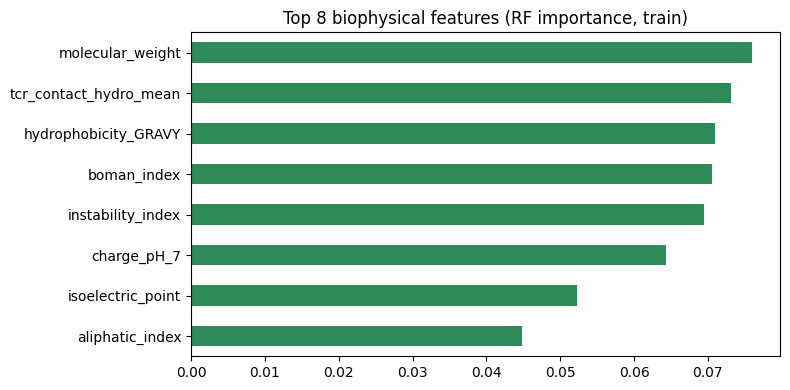

In [6]:
EXCLUDE = {"is_cancer", "Peptide Sequence", "Best HLA Allele"}
BIO_CANDIDATES = [c for c in train_df.columns
                  if c not in EXCLUDE and pd.api.types.is_numeric_dtype(train_df[c])]

_Xsel = (train_df[BIO_CANDIDATES].replace([np.inf, -np.inf], np.nan)
         .fillna(train_df[BIO_CANDIDATES].mean(numeric_only=True)).fillna(0))
_rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
_rf.fit(_Xsel, train_df["is_cancer"])
_imp = pd.Series(_rf.feature_importances_, index=BIO_CANDIDATES).sort_values(ascending=False)

TOP8 = _imp.head(N_TOP_BIO).index.tolist()
print("Full importance ranking:")
print(_imp.round(4).to_string())
print(f"\nTOP {N_TOP_BIO} biophysical features used by Stage 1:")
for i, f in enumerate(TOP8, 1):
    print(f"  {i}. {f}  ({_imp[f]:.4f})")

plt.figure(figsize=(8, 4))
_imp.head(N_TOP_BIO)[::-1].plot(kind="barh", color="seagreen")
plt.title(f"Top {N_TOP_BIO} biophysical features (RF importance, train)")
plt.tight_layout(); plt.show()

bio_scaler = StandardScaler().fit(_Xsel[TOP8].values)

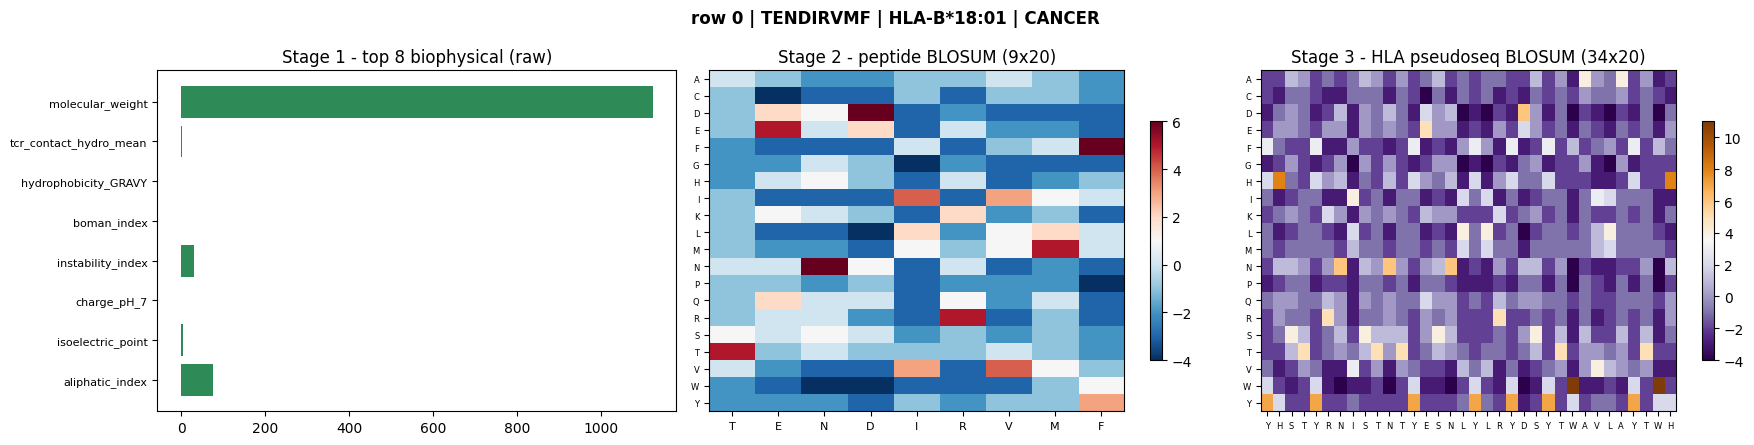

{'peptide': 'TENDIRVMF',
 'allele': 'HLA-B*18:01',
 'pseudoseq': 'YHSTYRNISTNTYESNLYLRYDSYTWAVLAYTWH',
 'label': 1,
 'top8': {'molecular_weight': 1124.2673,
  'tcr_contact_hydro_mean': 0.175,
  'hydrophobicity_GRAVY': -0.2556,
  'boman_index': -0.1889,
  'instability_index': 30.2889,
  'charge_pH_7': -1.5979,
  'isoelectric_point': 4.3682,
  'aliphatic_index': 75.5556}}

In [7]:
def visualize_row(frame, idx):
    row = frame.iloc[idx]
    pep, allele, label = row["Peptide Sequence"], row["Best HLA Allele"], int(row["is_cancer"])
    pep_enc = encode_blosum(pep)
    pseq = pseudo_map[allele]
    mhc_enc = encode_blosum(pseq)
    bio_vals = row[TOP8].astype(float).values

    fig = plt.figure(figsize=(18, 4.5))
    fig.suptitle(f"row {idx} | {pep} | {allele} | {'CANCER' if label else 'HEALTHY'}",
                 fontweight="bold")

    ax1 = fig.add_subplot(1, 3, 1)
    ax1.barh(TOP8[::-1], bio_vals[::-1], color="seagreen")
    ax1.set_title("Stage 1 - top 8 biophysical (raw)")
    ax1.tick_params(axis="y", labelsize=8)

    ax2 = fig.add_subplot(1, 3, 2)
    im2 = ax2.imshow(pep_enc.T, aspect="auto", cmap="RdBu_r")
    ax2.set_yticks(range(20)); ax2.set_yticklabels(_AAS, fontsize=6)
    ax2.set_xticks(range(len(pep))); ax2.set_xticklabels(list(pep), fontsize=8)
    ax2.set_title(f"Stage 2 - peptide BLOSUM ({pep_enc.shape[0]}x20)")
    fig.colorbar(im2, ax=ax2, shrink=0.7)

    ax3 = fig.add_subplot(1, 3, 3)
    im3 = ax3.imshow(mhc_enc.T, aspect="auto", cmap="PuOr_r")
    ax3.set_yticks(range(20)); ax3.set_yticklabels(_AAS, fontsize=6)
    ax3.set_xticks(range(len(pseq))); ax3.set_xticklabels(list(pseq), fontsize=6)
    ax3.set_title(f"Stage 3 - HLA pseudoseq BLOSUM ({mhc_enc.shape[0]}x20)")
    fig.colorbar(im3, ax=ax3, shrink=0.7)

    plt.tight_layout(); plt.show()
    return {"peptide": pep, "allele": allele, "pseudoseq": pseq,
            "label": label, "top8": dict(zip(TOP8, np.round(bio_vals, 4)))}

visualize_row(train_df, 0)

## 3. PyTorch Dataset + DataLoader

Each item returns the three modalities plus the label. Peptides are padded to `MAX_PEP_LEN` with a padding mask; the HLA pseudosequence is fixed length so it needs no padding.

In [8]:
class PeptideMHCDataset(Dataset):
    def __init__(self, frame, scaler):
        self.pep = frame["Peptide Sequence"].tolist()
        self.allele = frame["Best HLA Allele"].tolist()
        self.labels = frame["is_cancer"].astype(int).values
        bio = (frame[TOP8].replace([np.inf, -np.inf], np.nan)
               .fillna(frame[TOP8].mean(numeric_only=True)).fillna(0).values)
        self.bio = scaler.transform(bio).astype(np.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        pep_enc = encode_blosum(self.pep[i])                 # (L, 20)
        L = pep_enc.shape[0]
        pep_pad = np.zeros((MAX_PEP_LEN, 20), dtype=np.float32)
        pep_pad[:L] = pep_enc[:MAX_PEP_LEN]
        pad_mask = np.ones(MAX_PEP_LEN, dtype=bool)          # True = padding (ignored by attention)
        pad_mask[:min(L, MAX_PEP_LEN)] = False
        mhc_enc = encode_blosum(pseudo_map[self.allele[i]])  # (34, 20)
        return {
            "bio":      torch.from_numpy(self.bio[i]),
            "pep":      torch.from_numpy(pep_pad),
            "pep_mask": torch.from_numpy(pad_mask),
            "mhc":      torch.from_numpy(mhc_enc),
            "label":    torch.tensor(self.labels[i], dtype=torch.long),
        }

train_ds = PeptideMHCDataset(train_df, bio_scaler)
val_ds   = PeptideMHCDataset(val_df, bio_scaler)
test_ds  = PeptideMHCDataset(test_df, bio_scaler)

BATCH = 128
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=BATCH, shuffle=False)

# verify one batch
_b = next(iter(train_loader))
print("Batch shapes:")
for k, v in _b.items():
    print(f"  {k:9s}: {tuple(v.shape)}  {v.dtype}")
PSEUDO_LEN = len(PSEUDO_POS)

Batch shapes:
  bio      : (128, 8)  torch.float32
  pep      : (128, 11, 20)  torch.float32
  pep_mask : (128, 11)  torch.bool
  mhc      : (128, 34, 20)  torch.float32
  label    : (128,)  torch.int64


## 4. Multimodal model

Three encoders produce one vector each; the peptide cross-attends to the HLA groove (Stage 3); a multi-head attention layer fuses the three stage tokens; a linear head classifies.

In [9]:
class ThreeStageModel(nn.Module):
    def __init__(self, n_bio=N_TOP_BIO, d_model=64, n_heads=4, n_layers=2,
                 max_pep=MAX_PEP_LEN, dropout=0.2):
        super().__init__()
        self.d_model = d_model

        # Stage 1: biophysical MLP -> one token
        self.bio_mlp = nn.Sequential(
            nn.Linear(n_bio, d_model), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_model, d_model), nn.GELU(),
        )

        # Stage 2: peptide BLOSUM -> self-attention transformer (context) ->
        self.pep_proj = nn.Linear(20, d_model)
        self.pep_pos  = nn.Embedding(max_pep, d_model)
        enc_layer = nn.TransformerEncoderLayer(d_model, n_heads, d_model * 4,
                                               dropout, batch_first=True)
        self.pep_encoder = nn.TransformerEncoder(enc_layer, n_layers, enable_nested_tensor=False)

        # Stage 3: HLA groove tokens + peptide->MHC cross attention ("fold alongside")
        self.mhc_proj = nn.Linear(20, d_model)
        self.mhc_pos  = nn.Embedding(PSEUDO_LEN, d_model)
        self.cross_attn = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)

        # Fusion: multi-head attention over the 3 stage tokens, then linear head
        self.fusion_attn = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model * 3), nn.Linear(d_model * 3, d_model), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(d_model, 2),
        )

    def _masked_mean(self, x, pad_mask):
        keep = (~pad_mask).unsqueeze(-1).float()             # (B, L, 1)
        return (x * keep).sum(1) / keep.sum(1).clamp(min=1.0)

    def forward(self, bio, pep, pep_mask, mhc):
        B = bio.size(0)

        # Stage 1
        bio_tok = self.bio_mlp(bio)                          # (B, d)

        # Stage 2
        pos = torch.arange(pep.size(1), device=pep.device).unsqueeze(0)
        pep_x = self.pep_proj(pep) + self.pep_pos(pos)
        pep_x = self.pep_encoder(pep_x, src_key_padding_mask=pep_mask)   # (B, L, d)
        pep_tok = self._masked_mean(pep_x, pep_mask)         # (B, d)

        # Stage 3: peptide residues attend to HLA groove residues
        mpos = torch.arange(mhc.size(1), device=mhc.device).unsqueeze(0)
        mhc_x = self.mhc_proj(mhc) + self.mhc_pos(mpos)      # (B, 34, d)
        cross, _ = self.cross_attn(pep_x, mhc_x, mhc_x, key_padding_mask=None)  # (B, L, d)
        inter_tok = self._masked_mean(cross, pep_mask)       # (B, d)

        # Fusion: 3 tokens -> multi-head attention -> linear
        tokens = torch.stack([bio_tok, pep_tok, inter_tok], dim=1)   # (B, 3, d)
        fused, _ = self.fusion_attn(tokens, tokens, tokens)          # (B, 3, d)
        logits = self.classifier(fused.reshape(B, -1))               # (B, 2)
        return logits

model = ThreeStageModel().to(device)
print(model)
print("Trainable params:", sum(p.numel() for p in model.parameters() if p.requires_grad))

ThreeStageModel(
  (bio_mlp): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=64, bias=True)
    (4): GELU(approximate='none')
  )
  (pep_proj): Linear(in_features=20, out_features=64, bias=True)
  (pep_pos): Embedding(11, 64)
  (pep_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=256, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=256, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.2, inplace=Fals

## 5. Quality check / dry run

Push one batch through the model before training: confirm output shape, no NaNs, and that a loss backpropagates.

In [10]:
def to_device(batch):
    return (batch["bio"].to(device), batch["pep"].to(device),
            batch["pep_mask"].to(device), batch["mhc"].to(device),
            batch["label"].to(device))

model.train()
_b = next(iter(train_loader))
bio, pep, pep_mask, mhc, label = to_device(_b)
out = model(bio, pep, pep_mask, mhc)

assert out.shape == (bio.size(0), 2), f"bad output shape {out.shape}"
assert not torch.isnan(out).any(), "NaNs in output"

loss_fn = nn.CrossEntropyLoss()
loss = loss_fn(out, label)
loss.backward()
grad_norm = sum(p.grad.norm().item() for p in model.parameters() if p.grad is not None)

print("Output shape:", tuple(out.shape))
print("Logits sample:", out[0].detach().cpu().numpy().round(3))
print(f"Loss: {loss.item():.4f}  (ln2 = {np.log(2):.4f} expected at init)")
print(f"Total grad norm: {grad_norm:.4f}  -> backprop OK")
print("Dry run passed - no shape/NaN/grad alarms.")
model.zero_grad()

Output shape: (128, 2)
Logits sample: [0.049 0.102]
Loss: 0.6986  (ln2 = 0.6931 expected at init)
Total grad norm: 2.9380  -> backprop OK
Dry run passed - no shape/NaN/grad alarms.


## 6. Training + testing loops

Trains with early-stopping on validation accuracy; saves the best checkpoint; then evaluates on the held-out test set.

In [ ]:
def run_epoch(loader, train):
    model.train() if train else model.eval()
    total_loss, correct, n = 0.0, 0, 0
    torch.set_grad_enabled(train)
    for batch in loader:
        bio, pep, pep_mask, mhc, label = to_device(batch)
        logits = model(bio, pep, pep_mask, mhc)
        loss = loss_fn(logits, label)
        if train:
            optim.zero_grad(); loss.backward(); optim.step()
        total_loss += loss.item() * label.size(0)
        correct += (logits.argmax(1) == label).sum().item()
        n += label.size(0)
    torch.set_grad_enabled(True)
    return total_loss / n, correct / n

model = ThreeStageModel().to(device)
optim = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4) # Adam got to 82% accuracy on seed 42: 
loss_fn = nn.CrossEntropyLoss()

EPOCHS, PATIENCE = 30, 6
best_val, best_state, wait = 0.0, None, 0
ckpt = f"{CACHE_DIR}/threestage_classI_best.pt"
hist = {"train_acc": [], "val_acc": []}

for ep in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, True)
    va_loss, va_acc = run_epoch(val_loader, False)
    hist["train_acc"].append(tr_acc); hist["val_acc"].append(va_acc)
    print(f"Epoch {ep:02d} | train loss {tr_loss:.4f} acc {tr_acc:.4f} | val loss {va_loss:.4f} acc {va_acc:.4f}")
    if va_acc > best_val:
        best_val, best_state, wait = va_acc, {k: v.cpu().clone() for k, v in model.state_dict().items()}, 0
        torch.save(best_state, ckpt)
    else:
        wait += 1
        if wait >= PATIENCE:
            print(f"Early stopping at epoch {ep} (best val acc {best_val:.4f})")
            break

print(f"\nBest val accuracy: {best_val:.4f}  saved -> {ckpt}")

plt.figure(figsize=(7, 4))
plt.plot(hist["train_acc"], label="train")
plt.plot(hist["val_acc"], label="val")
plt.xlabel("epoch"); plt.ylabel("accuracy"); plt.legend(); plt.title("Training curve")
plt.tight_layout(); plt.show()

AttributeError: module 'torch.optim' has no attribute 'adam'

In [ ]:
# load best checkpoint and evaluate on the held-out test set
model.load_state_dict(torch.load(ckpt))
model.eval()

all_pred, all_true, all_prob = [], [], []
with torch.no_grad():
    for batch in test_loader:
        bio, pep, pep_mask, mhc, label = to_device(batch)
        logits = model(bio, pep, pep_mask, mhc)
        prob = torch.softmax(logits, 1)[:, 1]
        all_pred += logits.argmax(1).cpu().tolist()
        all_true += label.cpu().tolist()
        all_prob += prob.cpu().tolist()

print("===== TEST SET =====")
print(f"Accuracy:          {accuracy_score(all_true, all_pred):.4f}")
print(f"Balanced accuracy: {balanced_accuracy_score(all_true, all_pred):.4f}")
print(f"ROC AUC:           {roc_auc_score(all_true, all_prob):.4f}")
print("\nClassification report:")
print(classification_report(all_true, all_pred, target_names=["healthy", "cancer"], digits=4))

cm = confusion_matrix(all_true, all_pred)
fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(cm, cmap="Blues")
for (i, j), v in np.ndenumerate(cm):
    ax.text(j, i, str(v), ha="center", va="center", fontsize=12)
ax.set_xticks([0, 1]); ax.set_xticklabels(["healthy", "cancer"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["healthy", "cancer"])
ax.set_xlabel("predicted"); ax.set_ylabel("true"); ax.set_title("Test confusion matrix")
plt.tight_layout(); plt.show()

---
# Part 2 — V2 architecture: Two-Tower CNN + GAN feature stream

In [15]:
BIO_ALL = BIO_CANDIDATES                      
BIO_ALL = [f for f in BIO_ALL if f != "is_9mer"]
print(f"Biophysical features used by V2: {len(BIO_ALL)}")
# print all features
for i, f in enumerate(BIO_ALL, 1):
    print(f"  {i}. {f}")



scaler_all = StandardScaler().fit(
    train_df[BIO_ALL].replace([np.inf, -np.inf], np.nan)
            .fillna(train_df[BIO_ALL].mean(numeric_only=True)).fillna(0).values)

class PeptideMHCDatasetV2(Dataset):
    # returns all-bio vector + peptide BLOSUM matrix + HLA BLOSUM matrix + label
    def __init__(self, frame, scaler):
        self.pep = frame["Peptide Sequence"].tolist()
        self.allele = frame["Best HLA Allele"].tolist()
        self.labels = frame["is_cancer"].astype(int).values
        bio = (frame[BIO_ALL].replace([np.inf, -np.inf], np.nan)
               .fillna(frame[BIO_ALL].mean(numeric_only=True)).fillna(0).values)
        self.bio = scaler.transform(bio).astype(np.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        pe = encode_blosum(self.pep[i])
        pep = np.zeros((MAX_PEP_LEN, 20), dtype=np.float32)
        pep[:pe.shape[0]] = pe[:MAX_PEP_LEN]                 # zero-padded; CNN pools over length
        mhc = encode_blosum(pseudo_map[self.allele[i]])      # (34, 20)
        return {
            "bio":   torch.from_numpy(self.bio[i]),
            "pep":   torch.from_numpy(pep),
            "mhc":   torch.from_numpy(mhc),
            "label": torch.tensor(self.labels[i], dtype=torch.long),
        }

train_ds2 = PeptideMHCDatasetV2(train_df, scaler_all)
val_ds2   = PeptideMHCDatasetV2(val_df, scaler_all)
test_ds2  = PeptideMHCDatasetV2(test_df, scaler_all)

train_loader2 = DataLoader(train_ds2, batch_size=128, shuffle=True)
val_loader2   = DataLoader(val_ds2, batch_size=128, shuffle=False)
test_loader2  = DataLoader(test_ds2, batch_size=128, shuffle=False)

_b = next(iter(train_loader2))
print("V2 batch shapes:")
for k, v in _b.items():
    print(f"  {k:6s}: {tuple(v.shape)}  {v.dtype}")

Biophysical features used by V2: 39
  1. length
  2. molecular_weight
  3. charge_pH_7
  4. hydrophobicity_GRAVY
  5. isoelectric_point
  6. aromaticity
  7. instability_index
  8. helix_fraction
  9. sheet_fraction
  10. turn_fraction
  11. aliphatic_index
  12. boman_index
  13. tcr_contact_hydro_mean
  14. tcr_aromatic_count
  15. tcr_hydrophobic_count
  16. has_tryptophan
  17. tryptophan_at_tcr_pos
  18. hydrophobic_fraction
  19. has_aromatic_central
  20. aa_pct_A
  21. aa_pct_C
  22. aa_pct_D
  23. aa_pct_E
  24. aa_pct_F
  25. aa_pct_G
  26. aa_pct_H
  27. aa_pct_I
  28. aa_pct_K
  29. aa_pct_L
  30. aa_pct_M
  31. aa_pct_N
  32. aa_pct_P
  33. aa_pct_Q
  34. aa_pct_R
  35. aa_pct_S
  36. aa_pct_T
  37. aa_pct_V
  38. aa_pct_W
  39. aa_pct_Y
V2 batch shapes:
  bio   : (128, 39)  torch.float32
  pep   : (128, 11, 20)  torch.float32
  mhc   : (128, 34, 20)  torch.float32
  label : (128,)  torch.int64


### Stage 3 source — WGAN-GP critic as a peptide feature extractor

A Wasserstein GAN with gradient penalty is pretrained on the real training peptides (BLOSUM matrices). We then reuse the critic's penultimate layer as a learned peptide representation. The critic has **no batch-norm** (a WGAN-GP requirement) and the gradient penalty enforces the Lipschitz constraint.

In [16]:
LATENT_DIM, CRITIC_FEAT = 32, 64

class PeptideGenerator(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM, seq_len=MAX_PEP_LEN, n_aa=20):
        super().__init__()
        self.seq_len, self.n_aa = seq_len, n_aa
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 128), nn.ReLU(),
            nn.Linear(128, 256), nn.ReLU(),
            nn.Linear(256, seq_len * n_aa),
        )
    def forward(self, z):
        return self.net(z).view(-1, self.seq_len, self.n_aa)

class PeptideCritic(nn.Module):
    # conv feature extractor (no batch-norm) + linear Wasserstein score head
    def __init__(self, n_aa=20, feat_dim=CRITIC_FEAT):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(n_aa, 64, 3, padding=1), nn.LeakyReLU(0.2),
            nn.Conv1d(64, 128, 3, padding=1), nn.LeakyReLU(0.2),
            nn.AdaptiveAvgPool1d(1),
        )
        self.feat  = nn.Linear(128, feat_dim)
        self.score = nn.Linear(feat_dim, 1)
    def extract_features(self, x):                # x: (B, L, 20)
        h = self.conv(x.transpose(1, 2)).squeeze(-1)
        return torch.relu(self.feat(h))           # (B, feat_dim)
    def forward(self, x):
        return self.score(self.extract_features(x))

def gradient_penalty(critic, real, fake):
    B = real.size(0)
    eps = torch.rand(B, 1, 1, device=real.device)
    inter = (eps * real + (1 - eps) * fake).requires_grad_(True)
    s = critic(inter)
    g = torch.autograd.grad(s, inter, torch.ones_like(s),
                            create_graph=True, retain_graph=True)[0].reshape(B, -1)
    return ((g.norm(2, dim=1) - 1) ** 2).mean()

In [17]:
# Pretrain the WGAN-GP on real training peptides
GAN_EPOCHS, N_CRITIC, GP_LAMBDA = 5, 5, 10.0

_pep_real = torch.from_numpy(np.stack([
    (lambda e: np.vstack([e, np.zeros((MAX_PEP_LEN - e.shape[0], 20), np.float32)])[:MAX_PEP_LEN])
    (encode_blosum(s)) for s in train_df["Peptide Sequence"]
]).astype(np.float32))
gan_loader = DataLoader(torch.utils.data.TensorDataset(_pep_real), batch_size=128, shuffle=True)

G = PeptideGenerator().to(device)
C = PeptideCritic().to(device)
optG = torch.optim.Adam(G.parameters(), lr=1e-4, betas=(0.0, 0.9))
optC = torch.optim.Adam(C.parameters(), lr=1e-4, betas=(0.0, 0.9))

for ep in range(1, GAN_EPOCHS + 1):
    d_acc, g_acc, nb = 0.0, 0.0, 0
    for (real,) in gan_loader:
        real = real.to(device)
        B = real.size(0)
        # critic updates
        for _ in range(N_CRITIC):
            z = torch.randn(B, LATENT_DIM, device=device)
            fake = G(z).detach()
            loss_c = C(fake).mean() - C(real).mean() + GP_LAMBDA * gradient_penalty(C, real, fake)
            optC.zero_grad(); loss_c.backward(); optC.step()
        # generator update
        z = torch.randn(B, LATENT_DIM, device=device)
        loss_g = -C(G(z)).mean()
        optG.zero_grad(); loss_g.backward(); optG.step()
        d_acc += loss_c.item(); g_acc += loss_g.item(); nb += 1
    print(f"GAN epoch {ep:02d} | critic {d_acc/nb:+.3f} | gen {g_acc/nb:+.3f}")

torch.save(C.state_dict(), f"{CACHE_DIR}/wgan_critic.pt")
print("Critic pretrained and saved.")

GAN epoch 01 | critic -15.673 | gen -3.562
GAN epoch 02 | critic -25.276 | gen +7.349
GAN epoch 03 | critic -30.847 | gen +6.694
GAN epoch 04 | critic -28.277 | gen +3.185
GAN epoch 05 | critic -23.964 | gen +4.061
Critic pretrained and saved.


### V2 model — two-tower CNN + GAN-critic stream → multi-head attention → MLP

In [18]:
USE_GAN_STREAM = True     # ablation switch: set False to zero out the GAN stream
FREEZE_CRITIC  = True     # keep the pretrained critic fixed so its contribution is measurable

class CNNTower(nn.Module):
    # 1D CNN over residues; AdaptiveMaxPool handles any sequence length (peptide 11, HLA 34)
    def __init__(self, n_aa=20, out_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(n_aa, 64, 3, padding=1), nn.BatchNorm1d(64), nn.ReLU(),
            nn.Conv1d(64, 128, 3, padding=1), nn.BatchNorm1d(128), nn.ReLU(),
            nn.AdaptiveMaxPool1d(1),
        )
        self.fc = nn.Linear(128, out_dim)
    def forward(self, x):                          # x: (B, L, 20)
        h = self.net(x.transpose(1, 2)).squeeze(-1)
        return self.fc(h)

class TriModalModel(nn.Module):
    def __init__(self, n_bio, critic, d=64, n_heads=4, dropout=0.3,
                 use_gan=USE_GAN_STREAM, freeze_critic=FREEZE_CRITIC):
        super().__init__()
        self.use_gan, self.freeze_critic = use_gan, freeze_critic

        # Stream 2: biophysical MLP
        self.bio = nn.Sequential(
            nn.Linear(n_bio, 128), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(128, d), nn.GELU(),
        )
        # Stream 3: two-tower CNN (peptide + HLA), merged by concat
        self.towerA = CNNTower()                   # peptide
        self.towerB = CNNTower()                   # HLA groove
        self.tower_proj = nn.Linear(128, d)
        # Stream 1: GAN critic feature extractor
        self.critic = critic
        self.gan_proj = nn.Linear(CRITIC_FEAT, d)
        # Fusion: multi-head attention over the 3 tokens, then MLP head
        self.fusion = nn.MultiheadAttention(d, n_heads, dropout=dropout, batch_first=True)
        self.head = nn.Sequential(
            nn.LayerNorm(d * 3), nn.Linear(d * 3, 128), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(128, 2),
        )

    def forward(self, bio, pep, mhc):
        B = bio.size(0)
        bio_t = self.bio(bio)
        tower_t = self.tower_proj(torch.cat([self.towerA(pep), self.towerB(mhc)], dim=1))
        if self.use_gan:
            if self.freeze_critic:
                with torch.no_grad():
                    gf = self.critic.extract_features(pep)
            else:
                gf = self.critic.extract_features(pep)
            gan_t = self.gan_proj(gf)
        else:
            gan_t = torch.zeros(B, bio_t.size(1), device=bio.device)
        tokens = torch.stack([gan_t, bio_t, tower_t], dim=1)   # (B, 3, d)
        fused, _ = self.fusion(tokens, tokens, tokens)
        return self.head(fused.reshape(B, -1))

In [19]:
# Quality-check dry run for the V2 model
critic_pre = PeptideCritic().to(device)
critic_pre.load_state_dict(torch.load(f"{CACHE_DIR}/wgan_critic.pt"))
model2 = TriModalModel(n_bio=len(BIO_ALL), critic=critic_pre).to(device)

model2.train()
_b = next(iter(train_loader2))
bio, pep, mhc, label = _b["bio"].to(device), _b["pep"].to(device), _b["mhc"].to(device), _b["label"].to(device)
out = model2(bio, pep, mhc)
assert out.shape == (bio.size(0), 2), f"bad shape {out.shape}"
assert not torch.isnan(out).any(), "NaNs in output"
loss = nn.CrossEntropyLoss()(out, label)
loss.backward()
gn = sum(p.grad.norm().item() for p in model2.parameters() if p.grad is not None)
print("Output:", tuple(out.shape), "| loss", round(loss.item(), 4), "| grad norm", round(gn, 3))
print("V2 dry run passed - no shape/NaN/grad alarms.")
model2.zero_grad()

/var/folders/vs/1x2cctjj76q80zjkdspl6hd80000gn/T/ipykernel_15964/4281519289.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  critic_pre.load_state_dict(torch.load(f"{CACH

Output: (128, 2) | loss 0.7291 | grad norm 3.296
V2 dry run passed - no shape/NaN/grad alarms.


In [20]:
# Train + evaluate the V2 model
def run_epoch2(loader, train):
    model2.train() if train else model2.eval()
    tot, correct, n = 0.0, 0, 0
    torch.set_grad_enabled(train)
    for b in loader:
        bio, pep, mhc, label = b["bio"].to(device), b["pep"].to(device), b["mhc"].to(device), b["label"].to(device)
        logits = model2(bio, pep, mhc)
        loss = loss_fn2(logits, label)
        if train:
            opt2.zero_grad(); loss.backward(); opt2.step()
        tot += loss.item() * label.size(0)
        correct += (logits.argmax(1) == label).sum().item(); n += label.size(0)
    torch.set_grad_enabled(True)
    return tot / n, correct / n

critic_pre = PeptideCritic().to(device)
critic_pre.load_state_dict(torch.load(f"{CACHE_DIR}/wgan_critic.pt"))
model2 = TriModalModel(n_bio=len(BIO_ALL), critic=critic_pre).to(device)
opt2 = torch.optim.Adam(model2.parameters(), lr=1e-3, weight_decay=1e-4)
loss_fn2 = nn.CrossEntropyLoss()

EPOCHS2, PATIENCE2 = 25, 20
best_val2, wait = 0.0, 0
ckpt2 = f"{CACHE_DIR}/trimodal_classI_best.pt"
for ep in range(1, EPOCHS2 + 1):
    tr_l, tr_a = run_epoch2(train_loader2, True)
    va_l, va_a = run_epoch2(val_loader2, False)
    print(f"Epoch {ep:02d} | train loss {tr_l:.4f} acc {tr_a:.4f} | val loss {va_l:.4f} acc {va_a:.4f}")
    if va_a > best_val2:
        best_val2, wait = va_a, 0
        torch.save(model2.state_dict(), ckpt2)
    else:
        wait += 1
        if wait >= PATIENCE2:
            print(f"Early stopping at epoch {ep} (best val acc {best_val2:.4f})"); break
print(f"\nBest V2 val accuracy: {best_val2:.4f}")

model2.load_state_dict(torch.load(ckpt2)); model2.eval()
yp, yt, ypr = [], [], []
with torch.no_grad():
    for b in test_loader2:
        bio, pep, mhc, label = b["bio"].to(device), b["pep"].to(device), b["mhc"].to(device), b["label"].to(device)
        logits = model2(bio, pep, mhc)
        ypr += torch.softmax(logits, 1)[:, 1].cpu().tolist()
        yp += logits.argmax(1).cpu().tolist(); yt += label.cpu().tolist()

print("\n===== V2 TEST SET =====")
print(f"Accuracy:          {accuracy_score(yt, yp):.4f}")
print(f"Balanced accuracy: {balanced_accuracy_score(yt, yp):.4f}")
print(f"ROC AUC:           {roc_auc_score(yt, ypr):.4f}")
print(classification_report(yt, yp, target_names=["healthy", "cancer"], digits=4))

/var/folders/vs/1x2cctjj76q80zjkdspl6hd80000gn/T/ipykernel_15964/2307807994.py:18: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  critic_pre.load_state_dict(torch.load(f"{CAC

Epoch 01 | train loss 0.4360 acc 0.7851 | val loss 0.3819 acc 0.8189
Epoch 02 | train loss 0.3679 acc 0.8229 | val loss 0.3721 acc 0.8189
Epoch 03 | train loss 0.3635 acc 0.8229 | val loss 0.3859 acc 0.8221
Epoch 04 | train loss 0.3605 acc 0.8266 | val loss 0.3694 acc 0.8181
Epoch 05 | train loss 0.3530 acc 0.8291 | val loss 0.3775 acc 0.8236
Epoch 06 | train loss 0.3526 acc 0.8288 | val loss 0.3896 acc 0.8196
Epoch 07 | train loss 0.3479 acc 0.8333 | val loss 0.3687 acc 0.8242
Epoch 08 | train loss 0.3424 acc 0.8348 | val loss 0.3954 acc 0.8068
Epoch 09 | train loss 0.3391 acc 0.8354 | val loss 0.3859 acc 0.8102
Epoch 10 | train loss 0.3352 acc 0.8395 | val loss 0.4193 acc 0.8202
Epoch 11 | train loss 0.3265 acc 0.8427 | val loss 0.3898 acc 0.8108
Epoch 12 | train loss 0.3224 acc 0.8431 | val loss 0.4078 acc 0.8193
Epoch 13 | train loss 0.3140 acc 0.8496 | val loss 0.4021 acc 0.8155
Epoch 14 | train loss 0.3093 acc 0.8514 | val loss 0.4167 acc 0.8076
Epoch 15 | train loss 0.3033 acc 0

/var/folders/vs/1x2cctjj76q80zjkdspl6hd80000gn/T/ipykernel_15964/2307807994.py:39: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model2.load_state_dict(torch.load(ckpt2)); m


===== V2 TEST SET =====
Accuracy:          0.8283
Balanced accuracy: 0.8284
ROC AUC:           0.9217
              precision    recall  f1-score   support

     healthy     0.8355    0.8216    0.8285      3308
      cancer     0.8212    0.8351    0.8281      3244

    accuracy                         0.8283      6552
   macro avg     0.8283    0.8284    0.8283      6552
weighted avg     0.8284    0.8283    0.8283      6552

